In [1]:
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.patches import Patch

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

large_data_dir = gf_utils.large_data_dir

In [ ]:
gf_dir = large_data_dir + 'gf_CL_mega/BC1_giftwrap/'
adata_path = large_data_dir + 'CL_mega_WTA.h5ad'

manifest = gf_utils.get_manifest(gf_dir)

manifest['type'] = 'gapfill'
manifest.loc[manifest['name'] == 'SDHA c.1643A>G','gap_probe_sequence'] = 'GATG' ## manual fix

manifest.loc[manifest['name'].str.contains('0bp'),'type'] = '0bp_control'
manifest['variant'] = None ### not relevant for gapfill but maintained for consistency

probe_reads = gf_utils.get_input_probe_reads(gf_dir, read_threshold=0, min_percent_supporting=0.9, adata_path=adata_path)
probe_reads = probe_reads.merge(manifest[['gap_probe_sequence','gapfill_from_transcriptome','name','type','gapfill_start','variant']], left_on='probe_idx',right_index=True, how='left')

read_threshold = 10
probe_reads = probe_reads.loc[probe_reads['pcr_duplicate_count'] > read_threshold].copy()

probe_reads = probe_reads.loc[probe_reads['type'] == 'gapfill'].copy()

probe_counts_per_cell = probe_reads.groupby(['barcode','name']).size().reset_index()


43207807 UMIs found
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 43129460 UMIs remaining (99.82%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 38657371 UMIs remaining (89.47%)


In [3]:
genotyping_mode = 'gapfill'
betaine_condition = 'betaine'
adata = sc.read_h5ad('../output/' + genotyping_mode + '_' + betaine_condition + '_mega_genotyped_adata.h5ad')

In [4]:
## load GoT data and annotate cell types by genotyping

got_data = pd.read_csv('../data/GSM3309847_species_mix.CALR.txt',sep='\t',index_col=0)
got_data.loc[got_data['num.WT.call'] >= got_data['num.MUT.call'],'cell_type'] = 'UT-7'
got_data.loc[got_data['num.WT.call'] < got_data['num.MUT.call'],'cell_type'] = 'BA/F3'
got_data['color'] = got_data['cell_type'].map({'UT-7':'grey','BA/F3':'k'})

/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


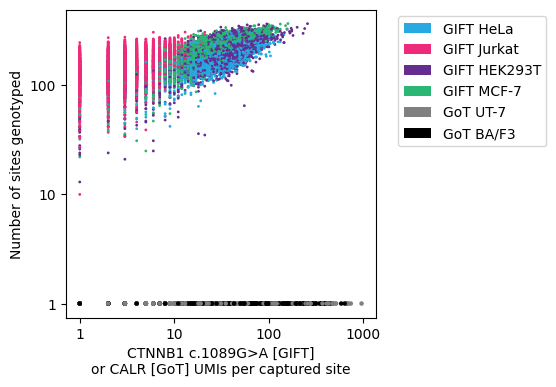

In [5]:
### plot best probe pair
to_plot = probe_counts_per_cell.loc[probe_counts_per_cell['name'] == 'CTNNB1 c.1089G>A'].set_index('barcode')[0].reindex(adata.obs_names).fillna(0).astype(float)
n_targets_genotyped = probe_counts_per_cell.groupby('barcode').size().reindex(adata.obs_names).fillna(0)

df = pd.DataFrame([to_plot, n_targets_genotyped, adata.obs['cell_type']]).transpose()
df.columns = ['counts','n_targets_genotyped','cell_type']
df['color'] = df['cell_type'].map({'HeLa':'#27aae1','Jurkat':'#ee2a7b','HEK293T':'#662d91','MCF-7':'#2bb673'})

fig,ax = plt.subplots(figsize=(4,4))
ax.scatter(np.log10(pd.to_numeric(df['counts'])), np.log10(pd.to_numeric(df['n_targets_genotyped'])),s=1,c=df['color'])
ax.set_xlabel('CTNNB1 c.1089G>A [GIFT]\n' \
'or CALR [GoT] UMIs per captured site')
ax.set_ylabel('Number of sites genotyped')

ax.scatter(np.log10(got_data[['num.WT.call','num.MUT.call']].sum(axis=1)), [np.log10(1)] * len(got_data), s=5,c=got_data['color'])

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['1', '10', '100'])

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['1', '10', '100', '1000'])


legend_elements = [Patch(facecolor='#27aae1', label='GIFT HeLa'),
                   Patch(facecolor='#ee2a7b', label='GIFT Jurkat'),
                   Patch(facecolor='#662d91', label='GIFT HEK293T'),
                   Patch(facecolor='#2bb673', label='GIFT MCF-7'),
                   Patch(facecolor='grey', label='GoT UT-7'),
                   Patch(facecolor='k', label='GoT BA/F3')]

ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('../plots/CL_mega_CTNNB1_vs_GoT_CALR.pdf', bbox_inches='tight', dpi=300)